Código adaptado de:

[1] Sebastian Raschka,Yuxi (Hayden) Liu e e Vahid Mirjalili. Machine Learning with PyTorch and Scikit-Learn. [capítulo 17] [(Github link)](https://github.com/rasbt/machine-learning-book)

Referências adicionais:

[1] T. Kynkäänniemi et al., “Improved Precision and Recall Metric for Assessing Generative Models,” Adv. Neural Inf. Process. Syst., vol. 32, no. NeurIPS, Apr. 2019. [(Paper link)](https://proceedings.neurips.cc/paper_files/paper/2019/file/0234c510bc6d908b28c70ff313743079-Paper.pdf)





# Laboratório 4: Precisão e Revocação de Variedades

## Importações

In [ ]:
!pip install prdc torchinfo

In [ ]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import Subset, DataLoader  # Subset permite criar subconjuntos de datasets, e DataLoader facilita o carregamento de dados em mini-lotes.
from torchvision import datasets            # Importa o módulo de conjuntos de dados do torchvision, que fornece acesso a conjuntos de dados populares como MNIST, CIFAR, etc. para visão computacional
from torchvision import transforms          # Importa o módulo de transforms do torchvision, usado para pré-processar imagens (conversão em tensor, normalização, etc.).
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import numpy as np                          # Importa a biblioteca NumPy, usada para operações numéricas eficientes com arrays e matrizes.
import matplotlib.pyplot as plt             # Importa o módulo de visualização matplotlib para gerar gráficos.
from IPython.display import Image           # Importa a classe Image do IPython, usada para exibir imagens diretamente dentro de notebooks.
import os                                   # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).
from prdc import compute_prdc               # Importa a função compute_prdc, usada para calcular as métricas de Precisão e Revocação para modelos generativos.
import seaborn as sns                       # Importa a biblioteca de visualização seaborn.
import pandas as pd                         # Importa a biblioteca pandas, usada para manipulação e análise de dados em estruturas como DataFrames.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # Define uma variável de ambiente para evitar conflitos de biblioteca durante a execução em alguns ambientes.

In [ ]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

In [ ]:
print("PyTorch version:", torch.__version__)            # Mostra a versão instalada do PyTorch
print("GPU Available:", torch.cuda.is_available())      # Indica se há GPU CUDA disponível
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" # Usa acelerador disponível (CUDA/MPS/XPU) ou então usa CPU

PyTorch version: 2.8.0+cu129
GPU Available: True


## Dados

In [ ]:
image_path = './'                                         # Define o diretório raiz onde o conjunto de dados MNIST será armazenado.

transform = transforms.Compose([                           # Define uma sequência de transformações a serem aplicadas às imagens do dataset.
    transforms.ToTensor(),                                 # Converte as imagens PIL em tensores PyTorch.
    transforms.Normalize(mean=(0.5), std=(0.5)),           # Normaliza os valores dos pixels para a faixa [-1, 1], com média 0.5 e desvio 0.5.
])

mnist_dataset = datasets.MNIST(root=image_path,            # Cria o objeto do dataset MNIST.
                               train=True,                 # Define que serão carregadas as imagens do conjunto de treinamento.
                               transform=transform,        # Aplica as transformações definidas acima a cada imagem carregada.
                               download=True)              # Faz o download do dataset caso ele não esteja presente no diretório especificado.

mnist_test = datasets.MNIST(root=image_path,               # Cria o objeto do dataset MNIST.
                               train=False,                # Define que serão carregadas as imagens do conjunto de teste.
                               transform=transform,        # Aplica as transformações definidas acima a cada imagem carregada.
                               download=True)              # Faz o download do dataset caso ele não esteja presente no diretório especificado.

print(f'mnist_dataset | mnist_test: {type(mnist_dataset)} | {type(mnist_test)}.')

example, label = next(iter(mnist_dataset))                 # Obtém o primeiro par (imagem, rótulo) do dataset MNIST.
print(f'Min: {example.min()} Max: {example.max()}')        # Exibe os valores mínimo e máximo do tensor da imagem (após normalização).
print(example.shape)                                       # Exibe o formato do tensor da imagem (para MNIST: [1, 28, 28]).

mnist_dataset | mnist_test: <class 'torchvision.datasets.mnist.MNIST'> | <class 'torchvision.datasets.mnist.MNIST'>.
Min: -1.0 Max: 1.0
torch.Size([1, 28, 28])


## GAN

### Hiperparâmetros

In [ ]:
image_size = (28, 28)        # Define o tamanho da imagem de saída (MNIST possui imagens de 28x28 pixels).
z_size = 20                  # Define o tamanho do vetor de ruído (dimensão do espaço latente usado pelo gerador).

gen_hidden_layers = 1        # Número de camadas ocultas no gerador.
gen_hidden_size = 100        # Número de neurônios na camada oculta do gerador.

disc_hidden_layers = 1       # Número de camadas ocultas no discriminador.
disc_hidden_size = 100       # Número de neurônios na camada oculta do discriminador.

torch.manual_seed(1)         # Fixa a semente para reprodutibilidade dos resultados gerados pelo PyTorch.

### Gerador

In [ ]:
gen_model = nn.Sequential(                                     # Define o gerador como uma rede sequencial (camadas empilhadas).
    nn.Linear(z_size, gen_hidden_size),                        # Camada linear totalmente conectada: entrada de tamanho z_size, saída com gen_hidden_size neurônios.
    nn.LeakyReLU(),                                            # Função de ativação LeakyReLU, que evita o problema de "neurônios mortos".
    nn.Linear(gen_hidden_size, np.prod(image_size)),           # Camada linear: transforma para o número total de pixels da imagem (28*28 = 784).
    nn.Tanh()                                                  # Função de ativação Tanh: garante que os valores de saída fiquem na faixa [-1, 1].
)

In [ ]:
summary(gen_model, input_size=(1, z_size))                     # Mostra um resumo detalhado da rede (torchinfo): camadas, parâmetros e shapes de entrada/saída.

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 784]                  --
├─Linear: 1-1                            [1, 100]                  2,100
├─LeakyReLU: 1-2                         [1, 100]                  --
├─Linear: 1-3                            [1, 784]                  79,184
├─Tanh: 1-4                              [1, 784]                  --
Total params: 81,284
Trainable params: 81,284
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.08
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.33
Estimated Total Size (MB): 0.33

### Discriminador

In [ ]:
disc_model = nn.Sequential(                                      # Define o discriminador como uma rede sequencial.
    nn.Linear(np.prod(image_size), disc_hidden_size, bias=False),# Camada linear: entrada com o número total de pixels (28*28 = 784), saída com disc_hidden_size neurônios. Sem termo de bias.
    nn.LeakyReLU(),                                              # Função de ativação LeakyReLU para introduzir não-linearidade.
    nn.Dropout(p=0.5),                                           # Camada de dropout com probabilidade de 50%.
    nn.Linear(disc_hidden_size, 1),                              # Camada linear final que reduz para uma única saída escalar.
    nn.Sigmoid()                                                 # Função sigmoide: comprime a saída para [0,1], interpretada como probabilidade de ser real.
)

In [ ]:
summary(disc_model, input_size=(1, np.prod(image_size)))         # Mostra um resumo da rede com torchinfo (camadas, parâmetros e shapes de entrada/saída).

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Linear: 1-1                            [1, 100]                  78,400
├─LeakyReLU: 1-2                         [1, 100]                  --
├─Dropout: 1-3                           [1, 100]                  --
├─Linear: 1-4                            [1, 1]                    101
├─Sigmoid: 1-5                           [1, 1]                    --
Total params: 78,501
Trainable params: 78,501
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.08
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.31
Estimated Total Size (MB): 0.32

### Gerar ruído

In [ ]:
def create_noise(batch_size, z_size, mode_z):               # Define a função create_noise para gerar vetores de ruído aleatório.
    if mode_z == 'uniform':                                 # Caso o modo de geração seja "uniform":
        input_z = torch.rand(batch_size, z_size)*2 - 1      # Gera amostras de ruído com distribuição uniforme em [-1, 1].
    elif mode_z == 'normal':                                # Caso o modo de geração seja "normal":
        input_z = torch.randn(batch_size, z_size)           # Gera amostras de ruído com distribuição normal padrão N(0,1).
    return input_z                                          # Retorna o lote de vetores de ruído gerados (tensor de shape [batch_size, z_size]).

### Treinamento da GAN

In [ ]:
batch_size = 64                                           # Define o tamanho do mini-lote (número de amostras processadas por iteração).
mode_z = 'uniform'                                        # Define o modo de geração do ruído: 'uniform' (U[-1,1]) ou 'normal' (N(0,1)).
torch.manual_seed(1)                                      # Fixa a semente para gerar números aleatórios reprodutíveis no PyTorch.
np.random.seed(1)                                         # Fixa a semente para gerar números aleatórios reprodutíveis no NumPy.

## Preparação do conjunto de dados
mnist_dl = DataLoader(mnist_dataset,                      # Cria um DataLoader para o conjunto MNIST.
                      batch_size=batch_size,              # Cada lote terá 64 imagens.
                      shuffle=True,                       # Embaralha os dados a cada época.
                      drop_last=True)                     # Descarta o último lote se não atingir o tamanho definido (64 imagens).

## Função de perda e otimizadores
loss_fn = nn.BCELoss()                                    # Define a função de perda: entropia cruzada binária (BCE: Binary Cross-Entropy).
g_optimizer = torch.optim.Adam(gen_model.parameters())    # Define o otimizador Adam para atualizar os parâmetros do gerador.
d_optimizer = torch.optim.Adam(disc_model.parameters())   # Define o otimizador Adam para atualizar os parâmetros do discriminador.

#### Treinamento do discriminador

In [ ]:
def d_train(x):                                                 # Define a função d_train para treinar o discriminador em um lote de dados.
    disc_model.zero_grad()                                      # Zera os gradientes acumulados do discriminador para evitar acúmulo entre iterações.

    # Treinamento do discriminador com um lote real
    batch_size = x.size(0)                                      # Obtém o tamanho do lote (número de amostras).
    x = x.view(batch_size, -1).to(device)                       # Redimensiona as imagens para vetores (batch_size, 784) e envia para o dispositivo.
    d_labels_real = torch.ones(batch_size, 1, device=device)    # Cria rótulos: 1 para amostras reais.

    d_proba_real = disc_model(x)                                # Passa as imagens reais pelo discriminador e obtém probabilidades de serem reais.
    d_loss_real = loss_fn(d_proba_real, d_labels_real)          # Calcula a perda do discriminador para o lote real.

    # Treinamento do discriminador com um lote falso
    input_z = create_noise(batch_size, z_size, mode_z).to(device) # Gera ruído aleatório e envia para o dispositivo.
    g_output = gen_model(input_z)                                 # O gerador produz imagens falsas a partir do ruído.

    d_proba_fake = disc_model(g_output)                         # Passa as imagens falsas pelo discriminador e obtém probabilidades de serem reais.
    d_labels_fake = torch.zeros(batch_size, 1, device=device)   # Cria rótulos: 0 para as amostras geradas.
    d_loss_fake = loss_fn(d_proba_fake, d_labels_fake)          # Calcula a perda do discriminador para o lote falso.

    # Retropropagação do gradiente e atualização dos parâmetros do discriminador
    d_loss = d_loss_real + d_loss_fake                          # Combina as perdas do lote real e falso.
    d_loss.backward()                                           # Propaga os gradientes da perda total.
    d_optimizer.step()                                          # Atualiza os parâmetros do discriminador.

    # Retorna a perda e as probabilidades previstas para análise
    return d_loss.item(), d_proba_real.detach(), d_proba_fake.detach()

#### Treinamento do gerador

In [ ]:
def g_train(x):                                              # Define a função g_train para treinar o gerador em um lote.
    gen_model.zero_grad()                                    # Zera os gradientes acumulados do gerador.

    batch_size = x.size(0)                                          # Obtém o tamanho do lote.
    input_z = create_noise(batch_size, z_size, mode_z).to(device)   # Gera ruído aleatório e envia para o dispositivo.
    g_labels_real = torch.ones(batch_size, 1, device=device)        # Define rótulos 1, pois o objetivo é que o D classifique as amostras geradas como reais.

    g_output = gen_model(input_z)                            # Produz amostras falsas a partir do ruído via gerador.
    d_proba_fake = disc_model(g_output)                      # Avalia as amostras geradas no discriminador.
    g_loss = loss_fn(d_proba_fake, g_labels_real)            # Calcula a perda do gerador comparando com rótulos 1.

    # Retropropagação do gradiente e atualização somente dos parâmetros do gerador
    g_loss.backward()                                        # Propaga os gradientes no grafo do gerador.
    g_optimizer.step()                                       # Atualiza os pesos do gerador.

    return g_loss.item()                                     # Retorna a perda.

#### Função auxiliar para gerar amostras a partir do gerador.

In [ ]:
def create_samples(g_model, input_z):
    g_output = g_model(input_z)                                  # Executa o gerador no ruído de entrada.
    images = torch.reshape(g_output, (batch_size, *image_size))  # Remodela para o formato de imagem (batch_size, 28, 28).
    return (images + 1) / 2.0                                    # Reescala de [-1, 1] para [0, 1] (compatível com visualização).

In [ ]:
fixed_z = create_noise(batch_size, z_size, mode_z).to(device)    # Ruído fixo para monitorar a evolução do gerador ao longo das épocas.

epoch_samples = []                                               # Lista para armazenar amostras geradas em épocas selecionadas.
all_d_losses = []                                                # Histórico da perda média do discriminador por época.
all_g_losses = []                                                # Histórico da perda média do gerador por época.
all_d_real = []                                                  # Histórico da saída média do discriminador para imagens reais por época.
all_d_fake = []                                                  # Histórico da saída média do discriminador para imagens falsas por época.

num_epochs = 50                                                  # Número total de épocas de treinamento.
torch.manual_seed(1)                                             # Fixa a semente para reprodutibilidade dos resultados.

for epoch in range(1, num_epochs + 1):                           # Loop principal de treinamento por época.
    d_losses, g_losses = [], []                                  # Listas temporárias para perdas por mini-lote na época atual.
    d_vals_real, d_vals_fake = [], []                            # Listas temporárias para saídas médias do discriminador em cada mini-lote.

    for i, (x, _) in enumerate(mnist_dl):                        # Itera sobre os mini-lotes do DataLoader.
        d_loss, d_proba_real, d_proba_fake = d_train(x)          # Treina o discriminador no mini-lote e obtém saídas.
        d_losses.append(d_loss)                                  # Registra a perda do discriminador no mini-lote.
        g_losses.append(g_train(x))                              # Treina o gerador no mini-lote e registra a perda.

        d_vals_real.append(d_proba_real.mean().cpu())            # Registra a média das probabilidades do discriminador para dados reais.
        d_vals_fake.append(d_proba_fake.mean().cpu())            # Registra a média das probabilidades do discriminador para dados falsos.

    all_d_losses.append(torch.tensor(d_losses).mean())           # Média das perdas do discriminador na época.
    all_g_losses.append(torch.tensor(g_losses).mean())           # Média das perdas do gerador na época.
    all_d_real.append(torch.tensor(d_vals_real).mean())          # Média das saídas do discriminador em amostras reais na época.
    all_d_fake.append(torch.tensor(d_vals_fake).mean())          # Média das saídas do discriminador em amostras falsas na época.

    print(f'Epoch {epoch:03d} | Avg Losses >>'                   # Imprime um resumo compacto da época.
          f' G/D {all_g_losses[-1]:.4f}/{all_d_losses[-1]:.4f}'
          f' [D-Real: {all_d_real[-1]:.4f} D-Fake: {all_d_fake[-1]:.4f}]')

    epoch_samples.append(create_samples(gen_model, fixed_z).detach().cpu().numpy()) # Armazena um lote de amostras geradas com ruído fixo para comparação.

Epoch 001 | Avg Losses >> G/D 0.9386/0.8127 [D-Real: 0.8579 D-Fake: 0.4603]
Epoch 002 | Avg Losses >> G/D 0.8321/1.1945 [D-Real: 0.5960 D-Fake: 0.4594]
Epoch 003 | Avg Losses >> G/D 0.9743/1.1666 [D-Real: 0.5913 D-Fake: 0.4115]
Epoch 004 | Avg Losses >> G/D 0.9807/1.2074 [D-Real: 0.5756 D-Fake: 0.4209]
Epoch 005 | Avg Losses >> G/D 0.9240/1.2484 [D-Real: 0.5601 D-Fake: 0.4385]
Epoch 006 | Avg Losses >> G/D 0.8964/1.2379 [D-Real: 0.5644 D-Fake: 0.4356]
Epoch 007 | Avg Losses >> G/D 1.0211/1.1865 [D-Real: 0.5805 D-Fake: 0.4063]
Epoch 008 | Avg Losses >> G/D 0.9822/1.2106 [D-Real: 0.5784 D-Fake: 0.4200]
Epoch 009 | Avg Losses >> G/D 0.9634/1.2207 [D-Real: 0.5769 D-Fake: 0.4254]
Epoch 010 | Avg Losses >> G/D 0.9495/1.2134 [D-Real: 0.5783 D-Fake: 0.4230]
Epoch 011 | Avg Losses >> G/D 0.9312/1.2219 [D-Real: 0.5772 D-Fake: 0.4283]
Epoch 012 | Avg Losses >> G/D 0.9634/1.2192 [D-Real: 0.5768 D-Fake: 0.4233]
Epoch 013 | Avg Losses >> G/D 0.9541/1.2112 [D-Real: 0.5805 D-Fake: 0.4223]
Epoch 014 | 

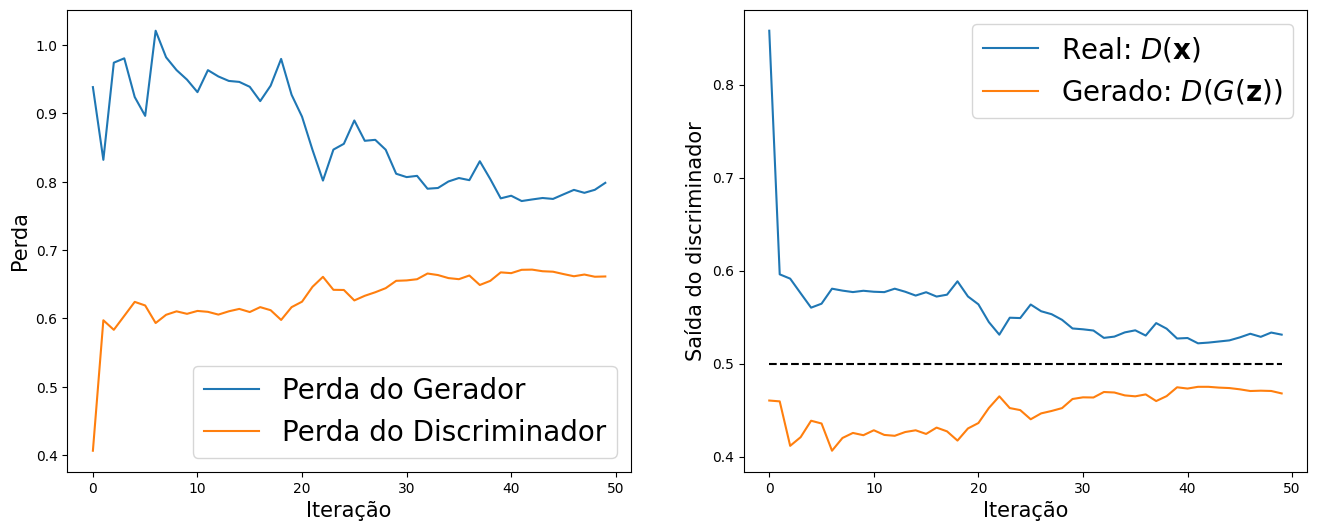

In [ ]:
fig = plt.figure(figsize=(16, 6))                               # Cria uma figura.

## Plotando as perdas (Generator e Discriminator)
ax = fig.add_subplot(1, 2, 1)                                   # Adiciona o primeiro subplot (linha 1, coluna 2, posição 1).

plt.plot(all_g_losses, label='Perda do Gerador')                # Plota a curva da perda média do gerador ao longo das épocas.
half_d_losses = [all_d_loss/2 for all_d_loss in all_d_losses]
plt.plot(half_d_losses, label='Perda do Discriminador')         # Plota a curva da perda média do discriminador.
plt.legend(fontsize=20)                                         # Exibe a legenda dos gráficos com fonte maior (tamanho 20).
ax.set_xlabel('Iteração', size=15)                              # Define o rótulo do eixo X como "Iteração".
ax.set_ylabel('Perda', size=15)                                 # Define o rótulo do eixo Y como "Perda".

## Plotando as saídas médias do discriminador
ax = fig.add_subplot(1, 2, 2)                                   # Adiciona o segundo subplot (linha 1, coluna 2, posição 2).
plt.plot(all_d_real, label=r'Real: $D(\mathbf{x})$')            # Plota a saída média do discriminador para imagens reais.
plt.plot(all_d_fake, label=r'Gerado: $D(G(\mathbf{z}))$')       # Plota a saída média do discriminador para imagens falsas.
plt.plot([0, len(all_d_real)-1], [0.5, 0.5], 'k--', label='')
plt.legend(fontsize=20)                                         # Exibe a legenda dos gráficos com fonte maior (tamanho 20).
ax.set_xlabel('Iteração', size=15)                              # Define o rótulo do eixo X como "Iteração".
ax.set_ylabel('Saída do discriminador', size=15)                # Define o rótulo do eixo Y como "Saída do discriminador".
plt.show()                                                      # Exibe a figura na tela.

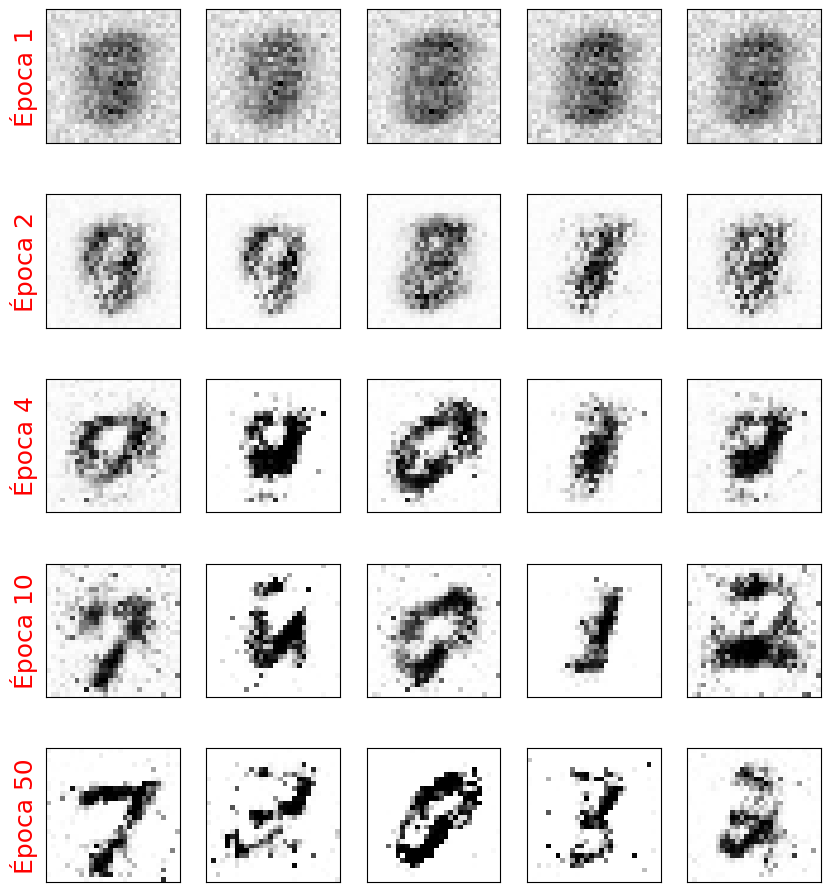

In [ ]:
selected_epochs = [1, 2, 4, 10, 50]                  # Lista de épocas selecionadas para visualização das amostras geradas.
fig = plt.figure(figsize=(10, 14))                        # Cria uma figura.

for i, e in enumerate(selected_epochs):                    # Itera sobre os índices e valores das épocas escolhidas.
    for j in range(5):                                     # Para cada época, seleciona 5 imagens geradas para exibir.
        ax = fig.add_subplot(6, 5, i*5 + j + 1)            # Cria um subplot na posição correspondente em uma grade 6x5.
        ax.set_xticks([])                                  # Remove os ticks do eixo X.
        ax.set_yticks([])                                  # Remove os ticks do eixo Y.

        if j == 0:                                         # Se for a primeira imagem da linha (coluna 0),
            ax.text(                                       # Adiciona um rótulo vertical indicando a época.
                -0.06, 0.5, f'Época {e}',                  # Texto indicando a época correspondente.
                rotation=90, size=18, color='red',         # Rotacionado em 90 graus, fonte maior e cor vermelha.
                horizontalalignment='right',               # Alinhamento horizontal à direita.
                verticalalignment='center',                # Alinhamento vertical centralizado.
                transform=ax.transAxes)                    # Usa coordenadas relativas ao eixo.

        image = epoch_samples[e-1][j]                      # Seleciona a j-ésima imagem gerada na época e.
        ax.imshow(image, cmap='gray_r')                    # Exibe a imagem em escala de cinza invertida (fundo branco, traços escuros).

plt.show()                                                 # Exibe a figura com todas as imagens.


## Classificador

#### Modelo

In [ ]:
# Classificador dividido em dois nn.Sequential: feature_extractor + classifier_head

# Extrator de features
feature_extractor = nn.Sequential(
    nn.Conv2d(1, 32, 3), nn.ReLU(), nn.MaxPool2d(2),    # -> (B,32,13,13)
    nn.Conv2d(32, 64, 3), nn.ReLU(), nn.MaxPool2d(2),   # -> (B,64,5,5)
    nn.Conv2d(64, 128, 3), nn.ReLU(),                   # -> (B,128,3,3)
    nn.AdaptiveAvgPool2d(1),                            # -> (B,128,1,1)
    nn.Flatten()                                        # -> (B,128)
).to(device)

# Cabeça classificadora
classifier_head = nn.Sequential(
    nn.Linear(128, 10)                                  # -> (B,10)
).to(device)

# Modelo completo
full_model = nn.Sequential(
    feature_extractor,
    classifier_head
).to(device)

In [ ]:
# Extrator de features
summary(feature_extractor, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 128]                  --
├─Conv2d: 1-1                            [1, 32, 26, 26]           320
├─ReLU: 1-2                              [1, 32, 26, 26]           --
├─MaxPool2d: 1-3                         [1, 32, 13, 13]           --
├─Conv2d: 1-4                            [1, 64, 11, 11]           18,496
├─ReLU: 1-5                              [1, 64, 11, 11]           --
├─MaxPool2d: 1-6                         [1, 64, 5, 5]             --
├─Conv2d: 1-7                            [1, 128, 3, 3]            73,856
├─ReLU: 1-8                              [1, 128, 3, 3]            --
├─AdaptiveAvgPool2d: 1-9                 [1, 128, 1, 1]            --
├─Flatten: 1-10                          [1, 128]                  --
Total params: 92,672
Trainable params: 92,672
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 3.12
Input size (MB): 0.00
Forward/backwa

In [ ]:
# Cabeça classificadora
summary(classifier_head, input_size=(1, 128))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Linear: 1-1                            [1, 10]                   1,290
Total params: 1,290
Trainable params: 1,290
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

In [ ]:
# Modelo completo
summary(full_model, input_size=(1, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Sequential: 1-1                        [1, 128]                  --
│    └─Conv2d: 2-1                       [1, 32, 26, 26]           320
│    └─ReLU: 2-2                         [1, 32, 26, 26]           --
│    └─MaxPool2d: 2-3                    [1, 32, 13, 13]           --
│    └─Conv2d: 2-4                       [1, 64, 11, 11]           18,496
│    └─ReLU: 2-5                         [1, 64, 11, 11]           --
│    └─MaxPool2d: 2-6                    [1, 64, 5, 5]             --
│    └─Conv2d: 2-7                       [1, 128, 3, 3]            73,856
│    └─ReLU: 2-8                         [1, 128, 3, 3]            --
│    └─AdaptiveAvgPool2d: 2-9            [1, 128, 1, 1]            --
│    └─Flatten: 2-10                     [1, 128]                  --
├─Sequential: 1-2                        [1, 10]                   --
│    └

#### Treinamento do classificador

In [ ]:
## Função de perda e otimizadores
loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.Adam(full_model.parameters(), lr=1e-3)

## Preparação do conjunto de dados
train_dl = DataLoader(mnist_dataset, batch_size=128, shuffle=True,  drop_last=True)
test_dl  = DataLoader(mnist_test,    batch_size=512, shuffle=False, drop_last=False)

In [ ]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()                                               # Coloca o modelo em modo de treinamento (ativa dropout, batchnorm, etc.)
    total_loss, total, correct = 0.0, 0, 0                      # Inicializa acumuladores de perda, número de exemplos e acertos
    for x, y in dataloader:                                     # Itera pelos lotes de dados
        x, y = x.to(device), y.to(device)                       # Move entradas e rótulos para o dispositivo (CPU/GPU)
        logits = model(x)                                       # Calcula as predições do modelo
        loss = loss_fn(logits, y)                               # Calcula a perda entre predições e rótulos
        optimizer.zero_grad()                                   # Zera gradientes acumulados
        loss.backward()                                         # Calcula gradientes via backpropagation
        optimizer.step()                                        # Atualiza os parâmetros do modelo
        total_loss += loss.item()                               # Acumula a perda do lote
        correct    += (logits.argmax(1) == y).sum().item()      # Conta acertos comparando previsão com rótulo
        total      += x.size(0)                                 # Conta número de exemplos processados
    return total_loss/total, correct/total                      # Retorna perda média por exemplo e acurácia

In [ ]:
@torch.no_grad()                                                 # Desativa o cálculo de gradientes (avaliação mais rápida e com menor uso de memória)
def evaluate(dataloader, model, loss_fn):
    model.eval()                                                 # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm usa estatísticas fixas)
    total_loss, total, correct = 0.0, 0, 0                       # Inicializa acumuladores de perda, número de exemplos e acertos
    for x, y in dataloader:                                      # Itera pelos lotes de dados
        x, y = x.to(device), y.to(device)                        # Move entradas e rótulos para o dispositivo (CPU/GPU)
        logits = model(x)                                        # Calcula as predições do modelo
        loss = loss_fn(logits, y)                                # Calcula a perda entre predições e rótulos
        total_loss += loss.item()                                # Acumula a perda do lote
        correct    += (logits.argmax(1) == y).sum().item()       # Conta acertos comparando previsão com rótulo
        total      += x.size(0)                                  # Conta número de exemplos processados
    return total_loss/total, correct/total                       # Retorna perda média por exemplo e acurácia

In [ ]:
n_epocas = 10                                                                                       # Define o número total de épocas de treinamento
for ep in range(n_epocas):                                                                          # Loop principal sobre as épocas
    tr_loss, tr_acc = train_one_epoch(train_dl, full_model, loss_fn, optimizer)                     # Executa uma época de treinamento e retorna perda/acurácia
    te_loss, te_acc = evaluate(test_dl, full_model, loss_fn)                                        # Avalia o modelo no conjunto de teste e retorna perda/acurácia
    print(f"Época {ep + 1}/{n_epocas} | Treinamento: perda={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"Teste: perda={te_loss:.4f} acc={te_acc:.3f}")                                          # Imprime resultados formatados de treino e teste


Época 1/10 | Treinamento: perda=0.4591 acc=0.861 | Teste: perda=0.1570 acc=0.950
Época 2/10 | Treinamento: perda=0.1277 acc=0.962 | Teste: perda=0.0853 acc=0.973
Época 3/10 | Treinamento: perda=0.0867 acc=0.973 | Teste: perda=0.0591 acc=0.983
Época 4/10 | Treinamento: perda=0.0668 acc=0.980 | Teste: perda=0.0542 acc=0.982
Época 5/10 | Treinamento: perda=0.0538 acc=0.984 | Teste: perda=0.0559 acc=0.982
Época 6/10 | Treinamento: perda=0.0459 acc=0.986 | Teste: perda=0.0463 acc=0.986
Época 7/10 | Treinamento: perda=0.0393 acc=0.988 | Teste: perda=0.0435 acc=0.987
Época 8/10 | Treinamento: perda=0.0342 acc=0.990 | Teste: perda=0.0336 acc=0.989
Época 9/10 | Treinamento: perda=0.0295 acc=0.991 | Teste: perda=0.0413 acc=0.988
Época 10/10 | Treinamento: perda=0.0279 acc=0.991 | Teste: perda=0.0296 acc=0.990


#### Extrator de características

In [ ]:
@torch.no_grad()                                                                                   # Desativa cálculo de gradientes (inferencia mais rápida e leve)
def get_features(dataset, feature_extractor, N: int, batch_size: int = 512) -> np.ndarray:
    feature_extractor.eval()                                                                        # Coloca o extrator de características em modo de avaliação
    N_eff = min(N, len(dataset))                                                                    # Garante que N não ultrapasse o tamanho do dataset
    subset = Subset(dataset, range(N_eff))                                                          # Seleciona os primeiros N exemplos do dataset
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False, drop_last=False)              # Cria um DataLoader sem embaralhar e sem descartar amostras

    feats_list = []                                                                                 # Lista para acumular os vetores de características
    for x, _ in loader:                                                                             # Itera sobre os lotes do DataLoader
        x = x.to(device)                                                                            # Move o batch de imagens para o dispositivo (CPU/GPU)
        emb = feature_extractor(x)                                                                  # Extrai features com o modelo
        feats_list.append(emb.detach().cpu().numpy().astype(np.float32))                            # Converte para NumPy float32 e adiciona à lista
    return np.concatenate(feats_list, axis=0)                                                       # Concatena todos os lotes em um único array (N, D)

In [ ]:
@torch.no_grad()                                                                                   # Desativa cálculo de gradientes (inferência mais rápida)
def get_features_from_generator(
    gen_model,
    feature_extractor,
    N: int,
    *,
    z_dim: int = z_size,
    mode_z: str = mode_z,
    batch: int = batch_size
) -> np.ndarray:

    gen_model.eval()                                                                                # Coloca o gerador em modo de avaliação
    feature_extractor.eval()                                                                        # Coloca o extrator em modo de avaliação

    feats = []                                                                                      # Lista para acumular as features
    remaining = N                                                                                   # Número de amostras restantes a serem geradas

    while remaining > 0:                                                                            # Gera em lotes até completar N
        cur = min(batch, remaining)                                                                 # Define o tamanho do lote atual
        z = create_noise(cur, z_dim, mode_z).to(device)                                             # Gera ruído latente (cur, z_dim) e move para o dispositivo
        imgs = gen_model(z).view(cur, 1, *image_size).to(device)                                    # Gera imagens (cur, 1, 28, 28) no intervalo [-1,1]
        emb  = feature_extractor(imgs)                                                              # Extrai as features das imagens geradas
        feats.append(emb.detach().cpu().numpy().astype(np.float32))                                 # Converte para NumPy float32 e acumula
        remaining -= cur                                                                            # Atualiza o contador de amostras restantes
    return np.concatenate(feats, axis=0)                                                            # Concatena todos as features em um array (N, D)

### Precisão e Revocação de Variedades

In [ ]:
dataset = mnist_test                                                                  # Usa o conjunto de teste MNIST
feature_extractor = full_model[0]                                                     # Seleciona apenas a parte extratora de características do classificador
N = 10_000                                                                            # Número de amostras a serem processadas
batch_size = 512                                                                      # Tamanho do mini-lote

#### Features das imagens reais

In [ ]:
real_features = get_features(                                                         # Extrai as features das N primeiras imagens do dataset
    dataset=dataset,
    feature_extractor=feature_extractor,
    N=N,
    batch_size=batch_size
)
print("real_features shape:", real_features.shape)                                    # Mostra o shape esperado: (N, dimensão do embedding), ex.: (10000, 128)


real_features shape: (10000, 128)


#### Features das imagens geradas

In [ ]:
fake_features = get_features_from_generator(                                          # Extrai as features das imagens geradas pelo gerador
    gen_model,                                                                        # Modelo gerador previamente treinado
    feature_extractor=feature_extractor,                                              # Extrator de características do classificador
    N=N,                                                                              # Número de imagens a serem geradas e processadas
    z_dim=z_size,                                                                     # Dimensão do vetor de ruído de entrada do gerador
    mode_z=mode_z,                                                                    # Distribuição do ruído (uniforme ou normal)
    batch=batch_size                                                                  # Tamanho do mini-lote para geração e extração
)
print("fake_features shape:", fake_features.shape)                                    # Mostra o shape esperado: (N, dimensão do embedding), ex.: (10000, 128)

fake_features shape: (10000, 128)


#### Precisão e revocação

In [ ]:
metrics = compute_prdc(real_features, fake_features, nearest_k=5)                     # Calcula métricas de Precisão e Revocação de Variedades (PRDC)
print(f"Precisão: {metrics['precision']:.4f}")                                        # Exibe a precisão
print(f"Revocação: {metrics['recall']:.4f}")                                          # Exibe a revocação

Num real: 10000 Num fake: 10000
Precisão: 0.7358
Revocação: 0.1081


In [ ]:
def mpr_curve_by_k(real_feats, fake_feats, ks):
    prec, rec = [], []                                               # Listas para armazenar precisão e revocação
    for k in ks:                                                     # Itera sobre os valores de k fornecidos
        print(f'Calculando MPR para k={k}...')                       # Mostra no console qual k está sendo processado
        m = compute_prdc(real_feats, fake_feats, nearest_k=k)        # Calcula precisão e revocação para o valor atual de k
        prec.append(m['precision'])                                  # Adiciona precisão calculada à lista
        rec.append(m['recall'])                                      # Adiciona revocação calculada à lista
    return np.array(rec), np.array(prec)                             # Retorna arrays de revocação e precisão

In [ ]:
def plot_mpr_curve(recall_arr, precision_arr, ks, title='Curva MPR (variando k)'):
    plt.figure()                                                              # Cria uma nova figura para o gráfico
    plt.plot(recall_arr, precision_arr, marker='o', label='GAN (FC)')         # Plota a curva de revocação vs. precisão
    for r, p, k in zip(recall_arr, precision_arr, ks):                        # Itera sobre cada ponto (r, p) com respectivo k
        plt.text(r, p, f'k={k}')                                              # Anota o valor de k próximo ao ponto correspondente
    plt.xlim(0, 1)                                                            # Define limites do eixo X entre 0 e 1
    plt.ylim(0, 1)                                                            # Define limites do eixo Y entre 0 e 1
    plt.xlabel('Revocação')                                                   # Rótulo do eixo X
    plt.ylabel('Precisão')                                                    # Rótulo do eixo Y
    plt.title(title)                                                          # Define o título do gráfico
    plt.grid(True)                                                            # Ativa a grade no gráfico
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))                    # Posiciona a legenda à esquerda fora da área do gráfico
    plt.show()                                                                # Exibe o gráfico na tela

In [ ]:
ks = list(range(1, 11))                                         # Define a lista de valores de k de 1 até 10
rec, prec = mpr_curve_by_k(real_features, fake_features, ks)    # Calcula arrays de revocação e precisão para cada k

Calculando MPR para k=1...
Num real: 10000 Num fake: 10000
Calculando MPR para k=2...
Num real: 10000 Num fake: 10000
Calculando MPR para k=3...
Num real: 10000 Num fake: 10000
Calculando MPR para k=4...
Num real: 10000 Num fake: 10000
Calculando MPR para k=5...
Num real: 10000 Num fake: 10000
Calculando MPR para k=6...
Num real: 10000 Num fake: 10000
Calculando MPR para k=7...
Num real: 10000 Num fake: 10000
Calculando MPR para k=8...
Num real: 10000 Num fake: 10000
Calculando MPR para k=9...
Num real: 10000 Num fake: 10000
Calculando MPR para k=10...
Num real: 10000 Num fake: 10000


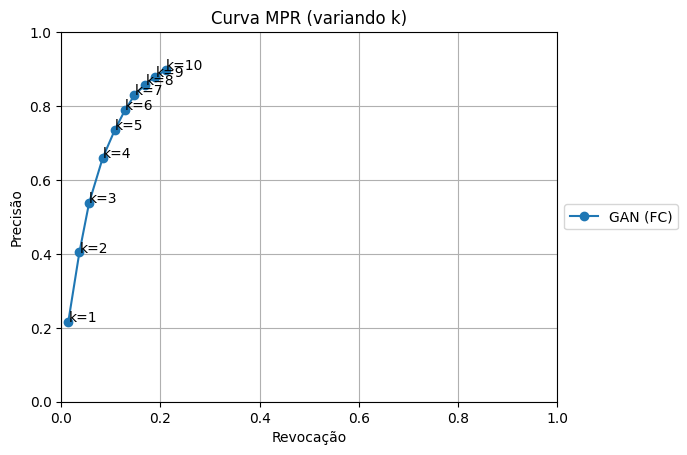

In [ ]:
plot_mpr_curve(rec, prec, ks, title='Curva MPR (variando k)')   # Plota a curva MPR de revocação vs. precisão para diferentes valores de k

In [ ]:
def mpr_sweep_Nk(
    mnist_test_dataset,
    gen_model,
    feature_extractor,
    Ns=(1000, 2500, 5000, 7500, 10000),
    ks=(3, 5, 10),
    *,
    model_name='GAN (FC)',
    batch_size=512,
    z_dim=None,
    mode_z=None
) -> pd.DataFrame:

    linhas = []                                                                                         # Lista para armazenar resultados intermediários
    for N in Ns:                                                                                        # Itera pelos diferentes valores de N
        real_feats = get_features(mnist_test_dataset, feature_extractor, N=N, batch_size=batch_size)    # Extrai features reais dos primeiros N exemplos
        fake_feats = get_features_from_generator(                                                       # Extrai features de N imagens geradas
            gen_model,
            feature_extractor,
            N=N,
            z_dim=z_dim,
            mode_z=mode_z,
            batch=batch_size
        )
        for k in ks:                                                                             # Itera sobre os diferentes valores de k
            m = compute_prdc(                                                                    # Calcula métricas de precisão e revocação
                real_features=real_feats.astype('float32'),
                fake_features=fake_feats.astype('float32'),
                nearest_k=k
            )
            linhas.append({                                                                      # Adiciona linha com resultados no formato dict
                'modelo':   model_name,
                'N':        int(N),
                'k':        int(k),
                'precision':float(m['precision']),
                'recall':   float(m['recall'])
            })
            print(f"[modelo={model_name}] N={N} | k={k} -> Precisão={m['precision']:.4f} | Revocação={m['recall']:.4f}")  # Exibe no console os resultados do par (N, k)

    return pd.DataFrame(linhas)                                                                  # Retorna um DataFrame com todos os resultados

In [ ]:
df_gan = mpr_sweep_Nk(                                           # Executa a varredura de N e k para calcular MPR
    mnist_test_dataset=mnist_test,                               # Conjunto de teste do MNIST usado para extrair features reais
    gen_model=gen_model,                                         # Gerador treinado que produz imagens sintéticas
    feature_extractor=full_model[0],                             # Extrator de características do classificador (parte inicial do modelo)
    Ns=(1000, 2500, 5000, 7500, 10000),                          # Conjunto de valores de N a serem testados
    ks=(3, 5, 10),                                               # Conjunto de valores de k a serem testados
    model_name='GAN (FC)',                                       # Nome do modelo para identificar os resultados no DataFrame
    batch_size=512,                                              # Tamanho dos lotes para processar dados
    z_dim=z_size,                                                # Dimensão do vetor de ruído do gerador
    mode_z=mode_z)                                               # Tipo de ruído usado (normal ou uniforme)

Num real: 1000 Num fake: 1000
[modelo=GAN (FC)] N=1000 | k=3 -> Precisão=0.7270 | Revocação=0.1810
Num real: 1000 Num fake: 1000
[modelo=GAN (FC)] N=1000 | k=5 -> Precisão=0.8870 | Revocação=0.3170
Num real: 1000 Num fake: 1000
[modelo=GAN (FC)] N=1000 | k=10 -> Precisão=0.9770 | Revocação=0.5430
Num real: 2500 Num fake: 2500
[modelo=GAN (FC)] N=2500 | k=3 -> Precisão=0.6792 | Revocação=0.1220
Num real: 2500 Num fake: 2500
[modelo=GAN (FC)] N=2500 | k=5 -> Precisão=0.8252 | Revocação=0.2064
Num real: 2500 Num fake: 2500
[modelo=GAN (FC)] N=2500 | k=10 -> Precisão=0.9560 | Revocação=0.4204
Num real: 5000 Num fake: 5000
[modelo=GAN (FC)] N=5000 | k=3 -> Precisão=0.5394 | Revocação=0.0872
Num real: 5000 Num fake: 5000
[modelo=GAN (FC)] N=5000 | k=5 -> Precisão=0.7536 | Revocação=0.1586
Num real: 5000 Num fake: 5000
[modelo=GAN (FC)] N=5000 | k=10 -> Precisão=0.9250 | Revocação=0.3016
Num real: 7500 Num fake: 7500
[modelo=GAN (FC)] N=7500 | k=3 -> Precisão=0.5175 | Revocação=0.0675
Num rea

In [ ]:
display(df_gan)   # Exibe o DataFrame df_gan em formato tabular

,modelo,N,k,precision,recall
0,GAN (FC),1000,3,0.727000,0.181000
1,GAN (FC),1000,5,0.887000,0.317000
2,GAN (FC),1000,10,0.977000,0.543000
3,GAN (FC),2500,3,0.679200,0.122000
4,GAN (FC),2500,5,0.825200,0.206400
5,GAN (FC),2500,10,0.956000,0.420400
6,GAN (FC),5000,3,0.539400,0.087200
7,GAN (FC),5000,5,0.753600,0.158600
8,GAN (FC),5000,10,0.925000,0.301600
9,GAN (FC),7500,3,0.517467,0.067467


In [ ]:
def plot_mpr_df(df: pd.DataFrame):

    modelos = df['modelo'].unique().tolist()                                      # Lista os nomes únicos de modelos presentes no DataFrame
    n_models = len(modelos)                                                       # Conta quantos modelos distintos existem

    fig, axes = plt.subplots(                                                     # Cria figura com subplots
        n_models, 2,                                                              # n_models linhas, 2 colunas (Precisão e Revocação)
        figsize=(12, 4 * n_models),                                               # Ajusta o tamanho da figura proporcional ao número de modelos
        dpi=110,                                                                  # Define resolução em pontos por polegada
        constrained_layout=True                                                   # Ajusta automaticamente os espaçamentos
    )

    if n_models == 1:                                                             # Caso haja apenas 1 modelo
        axes = np.array([axes])                                                   # Garante que axes seja indexável como array bidimensional

    for i, modelo in enumerate(modelos):                                          # Itera sobre cada modelo
        df_model = df[df['modelo'] == modelo].copy()                              # Filtra o DataFrame apenas para esse modelo

        ax_left = axes[i, 0]                                                      # Eixo à esquerda para precisão
        sns.lineplot(                                                             # Plota curva de precisão
            data=df_model, x='N', y='precision',
            hue='k', marker='o', ax=ax_left
        )
        ax_left.set_title(f'Precisão vs N ({modelo})')                            # Título do gráfico de precisão
        ax_left.set_xlabel('N (número de imagens reais = geradas)')               # Rótulo eixo X
        ax_left.set_ylabel('Precisão')                                            # Rótulo eixo Y
        ax_left.grid(True, linestyle='--', alpha=0.4)                             # Ativa grade com estilo tracejado
        ax_left.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='k')     # Legenda deslocada para a direita

        ax_right = axes[i, 1]                                                     # Eixo à direita para revocação
        sns.lineplot(                                                             # Plota curva de revocação
            data=df_model, x='N', y='recall',
            hue='k', marker='o', ax=ax_right
        )
        ax_right.set_title(f'Revocação vs N ({modelo})')                          # Título do gráfico de revocação
        ax_right.set_xlabel('N (número de imagens reais = geradas)')              # Rótulo eixo X
        ax_right.set_ylabel('Revocação')                                          # Rótulo eixo Y
        ax_right.grid(True, linestyle='--', alpha=0.4)                            # Ativa grade com estilo tracejado
        ax_right.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='k')    # Legenda deslocada para a direita

    plt.show()                                                                    # Exibe a figura final com todos os subplots

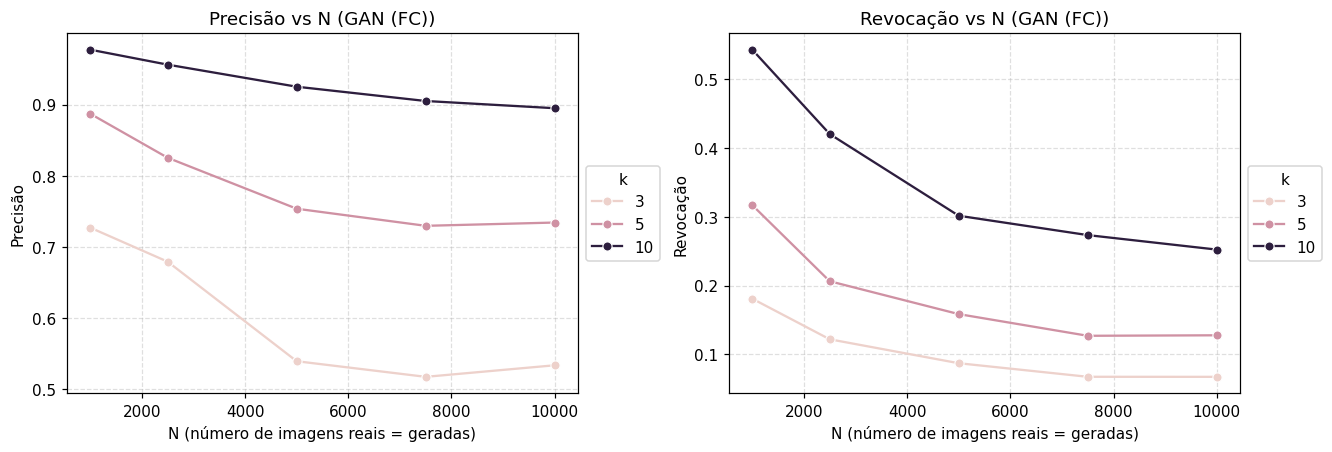

In [ ]:
plot_mpr_df(df_gan)   # Plota curvas de precisão e revocação para os resultados armazenados no DataFrame df_gan

# Tarefa (em duplas)

**Comparar uma GAN totalmente conectada, uma DCGAN e uma WGAN pelas métricas de precisão e revocação de variedades [*manifold precision and recall*], e investigar a sensibilidade dessas métricas aos parâmetros `k` e `N`**

Utilize o código acima como base e adapte-o para o seguinte problema:

1. Treine os três modelos generativos **não condicionais** abaixo com o conjunto de **treinamento** do MNIST (ou do Fashion-MNIST):

   - **GAN (FC)** - GAN totalmente conectada [*fully connected*];
   - **DCGAN** (convolucional);
   - **WGAN** (convolucional).

    Os três devem usar a **mesma dimensão de vetor latente e a mesma distribuição de ruído** (por exemplo, `z_dim = 100` e `mode_z = 'normal'`).

    Obs.: o código dos laboratórios anteriores pode ser reaproveitado; os modelos devem ser treinados neste laboratório.

2. Gere uma **grade de amostras aleatórias de cada modelo** (mesma quantidade de imagens e mesmo esquema de visualização para os três), para depois confrontar a inspeção visual com os valores das métricas.

3. Treine o **classificador** do código acima no conjunto de dados escolhido (MNIST ou Fashion-MNIST) e use o seu extrator de características como o **espaço de características comum aos três modelos**. Registre a acurácia de teste do classificador.

4. Trace a **curva MPR variando `k` de 1 a 10** para os três modelos, com as três curvas no mesmo gráfico e identificadas por legenda. Utilize o conjunto de **teste** para a aproximação da variedade dos dados reais, com `N = 10 000` imagens reais e `N = 10 000` imagens geradas.

    - Qual o comportamento da precisão e revocação ao se aumentar o valor de k?

5. Faça a **varredura em `N`** com `mpr_sweep_Nk`, usando `N=[1000, 2500, 5000, 7500, 10000]` e `k=[3, 5, 10]` para cada modelo. Concatene os resultados em um único `DataFrame` e plote com `plot_mpr_df`, que produz **uma linha de gráficos por modelo** (precisão vs `N` e revocação vs `N`).

**Observações:**

Mantenha constantes, para os três modelos, a dimensão do vetor latente, a distribuição do ruído, o extrator de características, o conjunto real e os valores de `N` e de `k`. Registre na tabela de experimentos os demais hiperparâmetros de treinamento de cada modelo.

**Entregáveis:**

Os entregáveis são **cumulativos ao longo da Unidade 1**. Ao final da unidade,
você entregará **apenas dois arquivos**, reunindo todos os laboratórios:

1. **Notebook** (`.ipynb`) — um único notebook com o código de todos os
   laboratórios da unidade, cada um em sua própria seção, na ordem em que foram
   realizados.

   O notebook deve **executar do início ao fim sem erros**, em um kernel novo,
   com *Restart & Run All*. Antes de entregar, execute-o dessa forma e confirme
   que todas as células rodam na ordem em que aparecem e que as saídas exibidas
   correspondem a essa execução. Notebooks que não executarem por completo serão
   penalizados.

2. **Relatório** (`.pdf`) — um único PDF, também organizado em seções, uma por
   laboratório.

Este laboratório corresponde à **Seção 4 — Precisão e Revocação de Variedades**, que deve conter:

- **Setup**: dados utilizados (conjunto, normalização aplicada e tamanho do
  lote), arquiteturas dos três geradores e do classificador, acurácia de teste
  do classificador e hiperparâmetros de treinamento de cada modelo. Apresente
  também uma tabela listando os três modelos comparados e, em cada um, o que
  difere da configuração base (a GAN totalmente conectada deste laboratório).
- **Resultados**:
  - grade de amostras aleatórias de cada um dos três modelos;
  - curva MPR variando `k` de 1 a 10, com as três curvas no mesmo gráfico;
  - três gráficos de precisão e revocação em função de `N`, para `k=3`, `5` e
    `10`, um para cada modelo.
- **Análise**: texto breve (5-10 linhas) discutindo, a partir da inspeção visual
  das figuras, o comportamento da precisão e da revocação ao se aumentar `k`, a
  ordenação dos três modelos em cada uma das duas métricas e a sua concordância
  com as grades de amostras, o valor de `N` a partir do qual as curvas se
  estabilizam, e eventuais casos de precisão alta com revocação baixa e o que
  sugerem sobre colapso de modos [*mode collapse*].

Nos próximos laboratórios da unidade, acrescente uma nova seção a cada arquivo,
preservando as anteriores.

O relatório **não** deve conter código.

A entrega é **única por grupo**. Identifique os integrantes no início do
notebook e na primeira página do relatório.